<a href="https://colab.research.google.com/github/minhtam3010050-jpg/TH_DEEP/blob/main/BT_TUAN3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ANN**

3.1. Nạp thư viện

In [3]:
# install required libraries
import pandas as pd
import numpy as np

# data visualization packages
!pip install scikeras
import matplotlib.pyplot as plt

# keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout

# Sửa lỗi ModuleNotFoundError: Thay thế keras.wrappers.scikit_learn bằng scikeras
from scikeras.wrappers import KerasClassifier

# model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

3.2. Đọc tập dữ liệu FASHION MNIST

In [4]:
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


3.3. Xử lý dữ liệu

In [5]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


3.4. Trực quan hóa dữ liệu

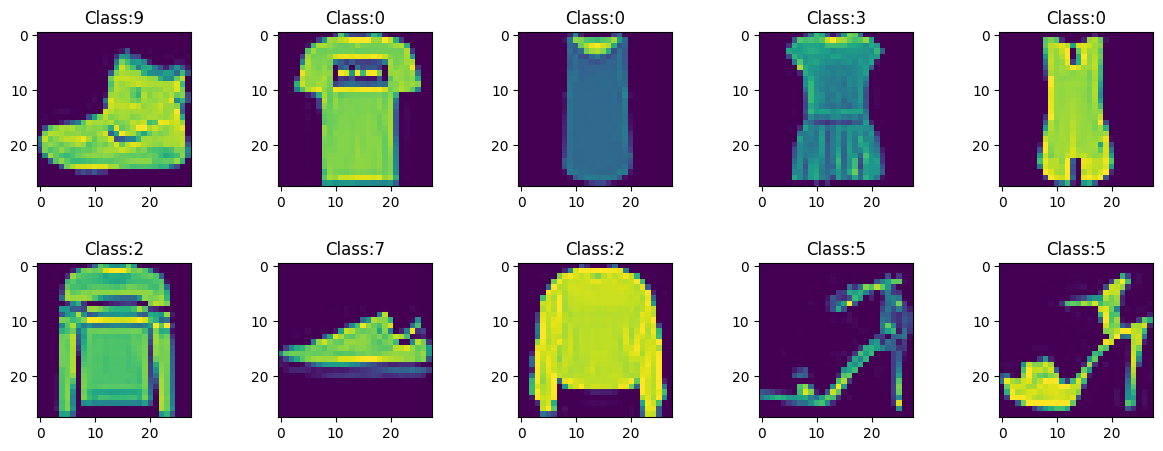

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

3.5. Xây dựng mô hình học ANN

In [7]:
fashion_model = Sequential()

fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

3.6. Huấn luyện ANN model

In [10]:
fashion_model = Sequential()

fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8196 - loss: 0.5035 - val_accuracy: 0.8613 - val_loss: 0.3863
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8666 - loss: 0.3675 - val_accuracy: 0.8523 - val_loss: 0.4111
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8803 - loss: 0.3291 - val_accuracy: 0.8697 - val_loss: 0.3481
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8892 - loss: 0.3036 - val_accuracy: 0.8767 - val_loss: 0.3452
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8939 - loss: 0.2865 - val_accuracy: 0.8887 - val_loss: 0.3200
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8993 - loss: 0.2728 - val_accuracy: 0.8853 - val_loss: 0.3298
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9026 - loss: 0.2599 - val_accuracy: 0.8895 - val_loss: 0.3195
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9090 - loss: 0.2469 -

3.7. Đánh giá ANN model

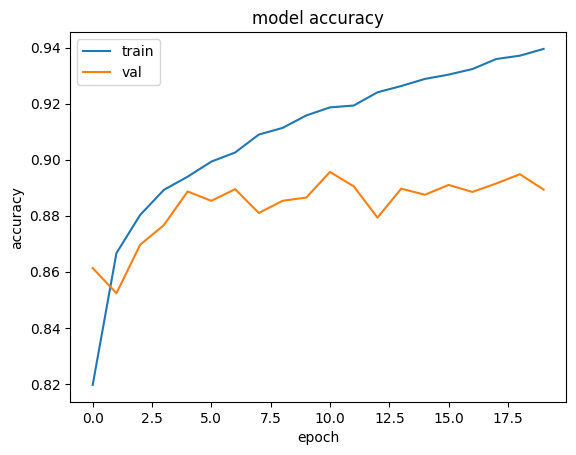

In [11]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

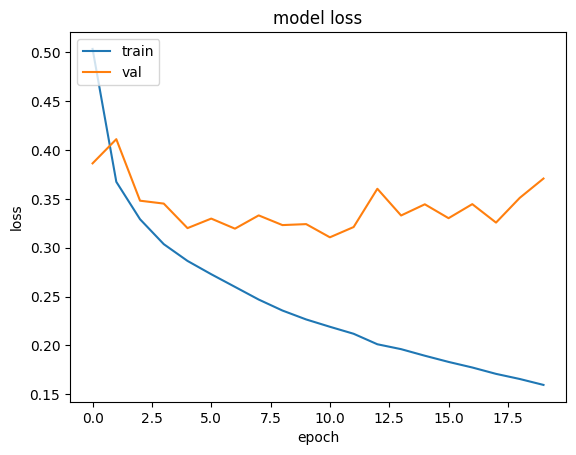

In [12]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

3.8. Dự báo ảnh mới

In [13]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
4 4


3.9. Đọc tập dữ liệu từ file

In [15]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Kích thước X_train:", X_train.shape)
print("Số lượng nhãn độc nhất:", len(np.unique(y_train)))

Kích thước X_train: (60000, 784)
Số lượng nhãn độc nhất: 10


In [18]:
import tensorflow as tf
import numpy as np

fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print('X_train shape:', X_train.shape)
print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

X_train shape: (60000, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [19]:
# [10]
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense
# [15]
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8239 - loss: 0.4949
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8676 - loss: 0.3661
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8809 - loss: 0.3257
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8885 - loss: 0.3047
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8932 - loss: 0.2860
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8988 - loss: 0.2718
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9046 - loss: 0.2578
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9088 - loss: 0.2473
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9108 - loss: 0.2370
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9136 - loss: 0.2282
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9178 - loss: 0.2200
Epoch 12/30
1875/1875 ━━━━

In [21]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
9 9


In [25]:
import numpy as np
import tensorflow as tf

fake_img = np.random.randint(0, 256, size=(28, 28), dtype=np.uint8)

img_flatten = fake_img.reshape(784)
img_flatten = img_flatten.astype('float32') / 255.0

img_tensor = tf.expand_dims(img_flatten, 0)
print("Kích thước đầu vào predict giả lập:", img_tensor.shape)

img_predict = model.predict(img_tensor)
print("Xác suất các lớp:\n", img_predict)
score = np.argmax(img_predict)
print("Lớp dự đoán được (Class):", score)

Kích thước đầu vào predict giả lập: (1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Xác suất các lớp:
 [[6.1460332e-31 8.5975459e-17 6.3002054e-18 0.0000000e+00 2.0852186e-17
  6.5759169e-25 1.1952904e-10 0.0000000e+00 1.0000000e+00 2.7380845e-24]]
Lớp dự đoán được (Class): 8


**4**. **BÀI** **TẬP**

1. Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow
với các nhãn sau

In [26]:

cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Kích thước dữ liệu CIFAR-10:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Kích thước dữ liệu CIFAR-10:
X_train: (50000, 3072)  | y_train: (50000, 1)


In [27]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

model_cifar = Sequential()

model_cifar.add(Dense(input_dim=X_train.shape[1], units=512, kernel_initializer='uniform', activation='relu'))
model_cifar.add(Dropout(0.2)) # Tránh quá khớp (overfitting)

model_cifar.add(Dense(units=256, kernel_initializer='uniform', activation='relu'))

model_cifar.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model_cifar.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_cifar = model_cifar.fit(X_train, y_train, validation_split=0.1, epochs=20, batch_size=64, verbose=1)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.3087 - loss: 1.8933 - val_accuracy: 0.3580 - val_loss: 1.7746
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.3703 - loss: 1.7483 - val_accuracy: 0.3994 - val_loss: 1.6753
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3968 - loss: 1.6832 - val_accuracy: 0.4082 - val_loss: 1.6511
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.4114 - loss: 1.6401 - val_accuracy: 0.4436 - val_loss: 1.6009
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.4233 - loss: 1.6088 - val_accuracy: 0.4460 - val_loss: 1.5553
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.4321 - loss: 1.5821 - val_accuracy: 0.4658 - val_loss: 1.5164
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.4422 - loss: 1.5571 - val_accuracy: 0.4548 - val_loss: 1.5395
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.4451 - loss: 1.5404 - 

In [28]:
test_loss, test_acc = model_cifar.evaluate(X_test, y_test, verbose=0)
print(f"Độ chính xác trên tập Test (CIFAR-10): {test_acc * 100:.2f}%")

Độ chính xác trên tập Test (CIFAR-10): 49.61%


2. Viết chương trình cài đặt ANN để nhận dạng ảnh chữ viết số trên bộ dataset MNIST do giảng viên
cung cấp với các nhãn sau

In [29]:

mnist = tf.keras.datasets.mnist
(X_train_mn, y_train_mn), (X_test_mn, y_test_mn) = mnist.load_data()
X_train_mn = X_train_mn.reshape(60000, 784)
X_test_mn = X_test_mn.reshape(10000, 784)

X_train_mn = X_train_mn.astype('float32') / 255.0
X_test_mn = X_test_mn.astype('float32') / 255.0

print("Kích thước dữ liệu MNIST:")
print("X_train_mn:", X_train_mn.shape, " | y_train_mn:", y_train_mn.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước dữ liệu MNIST:
X_train_mn: (60000, 784)  | y_train_mn: (60000,)


In [30]:
from keras.models import Sequential
from keras.layers import Dense

model_mnist = Sequential()

model_mnist.add(Dense(input_dim=X_train_mn.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

model_mnist.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

model_mnist.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_mnist = model_mnist.fit(X_train_mn, y_train_mn, validation_split=0.1, epochs=20, batch_size=64, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9120 - loss: 0.3229 - val_accuracy: 0.9658 - val_loss: 0.1351
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9612 - loss: 0.1332 - val_accuracy: 0.9717 - val_loss: 0.0981
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9727 - loss: 0.0900 - val_accuracy: 0.9742 - val_loss: 0.0863
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9806 - loss: 0.0658 - val_accuracy: 0.9782 - val_loss: 0.0744
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9854 - loss: 0.0495 - val_accuracy: 0.9805 - val_loss: 0.0703
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9891 - loss: 0.0378 - val_accuracy: 0.9805 - val_loss: 0.0708
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9913 - loss: 0.0300 - val_accuracy: 0.9802 - val_loss: 0.0717
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9934 - loss: 0.0230 - val_accuracy: 

In [31]:
test_loss_mn, test_acc_mn = model_mnist.evaluate(X_test_mn, y_test_mn, verbose=0)
print(f"Độ chính xác trên tập Test (MNIST): {test_acc_mn * 100:.2f}%")

Độ chính xác trên tập Test (MNIST): 98.12%


**CNN**

2.1 Nạp thư viện

In [32]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

2.2. Đọc dữ liệu MNIST

In [33]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [34]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


2.3. Trực quan hóa 10 ảnh đầu tiên

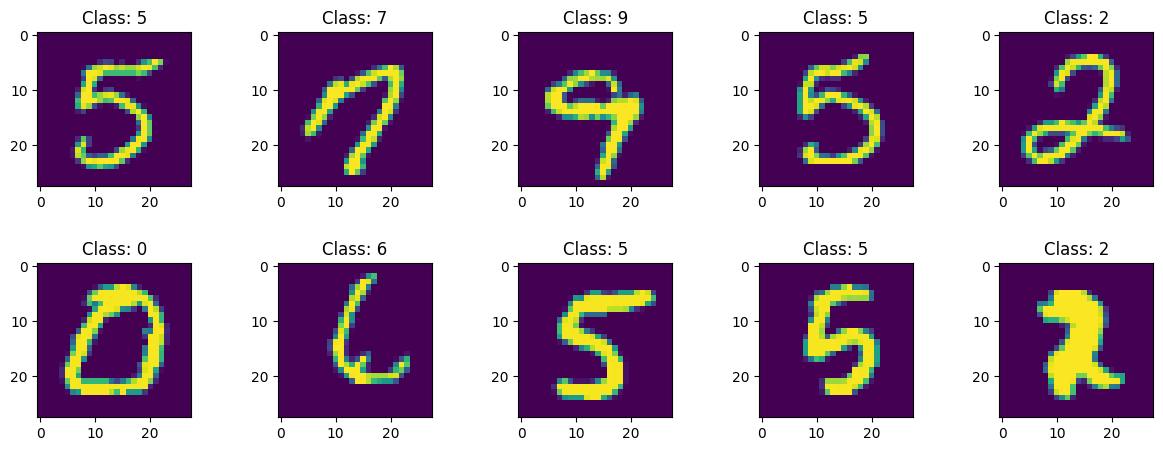

In [35]:
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28,28))
  ax[i].title.set_text('Class: '+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

2.4. Chuyển giá trị nhãn thành one-hot encoding

In [37]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


2.5. Xây dựng mô hình CNN

In [38]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10,activation='softmax'))
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

2.6. Huấn luyện mô hình CNN

In [43]:
y_train = np.array(df_train.iloc[:, 0]).flatten()
y_test = np.array(df_test.iloc[:, 0]).flatten()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_fit = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.8347 - loss: 0.6059 - val_accuracy: 0.9290 - val_loss: 0.2330
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.9534 - loss: 0.1525 - val_accuracy: 0.9620 - val_loss: 0.1300
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9705 - loss: 0.1008 - val_accuracy: 0.9690 - val_loss: 0.1204
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9766 - loss: 0.0791 - val_accuracy: 0.9720 - val_loss: 0.0985
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9801 - loss: 0.0616 - val_accuracy: 0.9735 - val_loss: 0.0929
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9823 - loss: 0.0539 - val_accuracy: 0.9735 - val_loss: 0.0906
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9851 - loss: 0.0469 - val_accuracy: 0.9750 - val_loss: 0.0890
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9877 - loss: 0.0421 - val

2.7. Đánh giá mô hình CNN

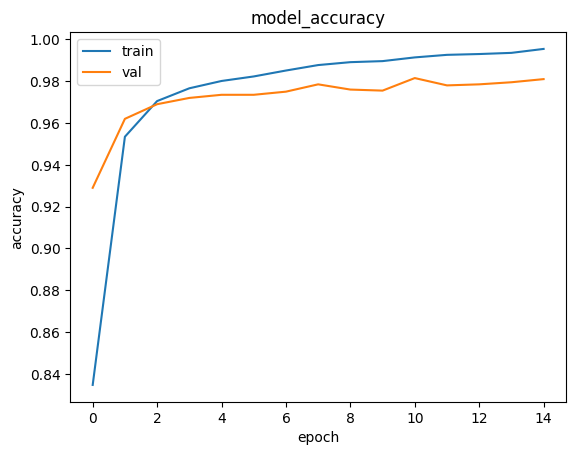

In [44]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model_accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()

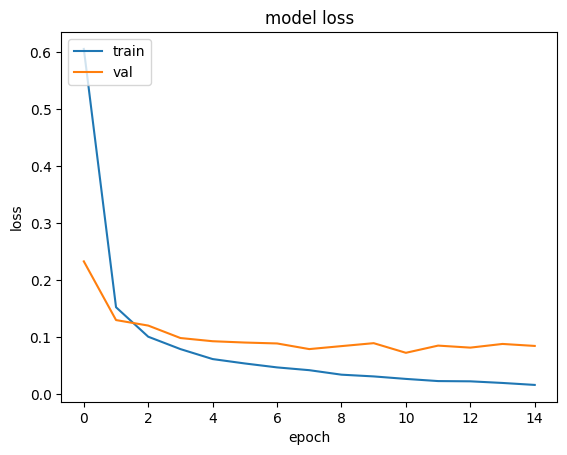

In [45]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','val'], loc='upper left')
plt.show()

2.8. Đánh giá mô hình CNN thử nghiệm trên tập test

In [46]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 7ms/step - accuracy: 0.9820 - loss: 0.0636
Test loss: 0.06358615309000015
Test accuracy: 0.9819982051849365


2.9. Dự báo nhãn cho ảnh sử dụng CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[9.5735313e-06 6.3338914e-05 9.9992716e-01 2.9181036e-11 7.0285961e-19
  2.0035177e-14 4.1150276e-08 8.1470415e-17 1.8758360e-08 2.8363761e-20]]
2 0


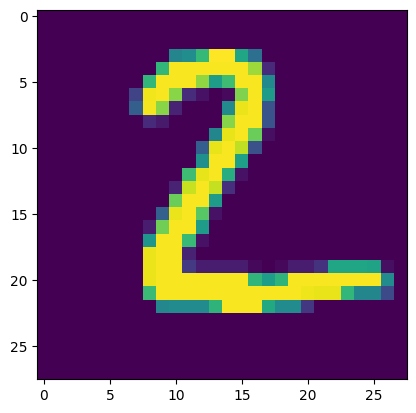

In [47]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

2.10. Lưu tham số mô hình CNN

In [49]:
model.save_weights('cnn.weights.h5')

2.11. Nạp lại mô hình và tham số

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
[[1.97095076e-07 9.99938369e-01 6.17179285e-06 9.99808947e-08
  1.27570811e-05 2.39029596e-08 1.17390094e-07 6.86990279e-06
  3.54923104e-05 4.79032147e-09]]
1 0


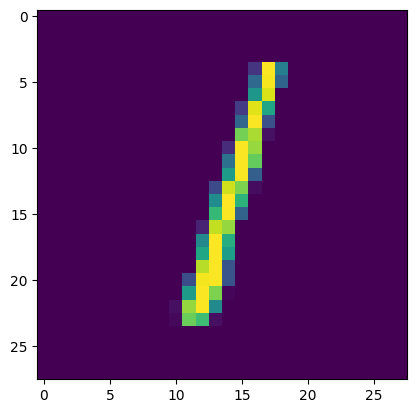

In [50]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
# Lưu ý sửa đuôi thành '.weights.h5' nếu bạn đang dùng Keras 3 như lỗi ở bước trước
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

**3. BÀI TẬP**

1. Viết chương trình cài đặt CNN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow
với các nhãn sau

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.4126 - loss: 1.6053 - val_accuracy: 0.5162 - val_loss: 1.3621
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.5605 - loss: 1.2382 - val_accuracy: 0.5958 - val_loss: 1.1453
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.6170 - loss: 1.0870 - val_accuracy: 0.6206 - val_loss: 1.0785
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.6567 - loss: 0.9816 - val_accuracy: 0.6716 - val_loss: 0.9682
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.6810 - loss: 0.9129 - val_accuracy: 0.6898 - val_loss: 0.9108
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.7015 - loss: 0.8543 - val_accuracy: 0.6906 - val_loss: 0.8953
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.7196 - loss: 0.7977 - val_accuracy: 0.7040 - val_loss: 0.8577
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 49ms/step - accuracy: 0.7341 - loss: 0.7549 - 


Test accuracy đạt được: 69.91%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Nhãn dự đoán (Số): 3 -> Tên nhãn: cat
Nhãn thực tế (Số): 3 -> Tên nhãn: cat


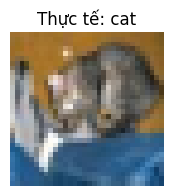

In [52]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np





(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
model = models.Sequential()
model.add(layers.Input(shape=(32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(X_train, y_train,
                    batch_size=64,
                    epochs=15,
                    validation_split=0.1,
                    verbose=1)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest accuracy đạt được: {test_acc * 100:.2f}%')
predict = model.predict(X_test[0:1])
predicted_label = np.argmax(predict)
actual_label = y_test[0][0]
print(f"Nhãn dự đoán (Số): {predicted_label} -> Tên nhãn: {class_names[predicted_label]}")
print(f"Nhãn thực tế (Số): {actual_label} -> Tên nhãn: {class_names[actual_label]}")
plt.figure(figsize=(2,2))
plt.imshow(X_test[0])
plt.title(f"Thực tế: {class_names[actual_label]}")
plt.axis('off')
plt.show()